In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns


In [ ]:
file = "/home/zhe2/FraLab/PACE_redSIF_PACE/demo_example/pseudo_measurement_discard/sif_addition_output/interim_20250927T123954_sif_addition_retrieval.nc"
ds = xr.open_dataset(file)

# ds = ds.isel(scans=slice(600,615), pixels=slice(200,300))
# lat and lon
lat = ds["latitude"]
lon = ds["longitude"]
# truth added sif
sif_added_truth = ds["sif_added_678nm"]
# retrieval sif (raw w/o addition)
sif_retrieval = ds["sif_radiance_678nm_without_sif"]
# retrieved sif (w/ addition)
sif_retrieval_added = ds["sif_radiance_678nm_with_sif"]
# convergence flag
converged_with_sif = ds["converged_with_sif"]
converged_without_sif = ds["converged_without_sif"]


array([0, 1], dtype=uint8)

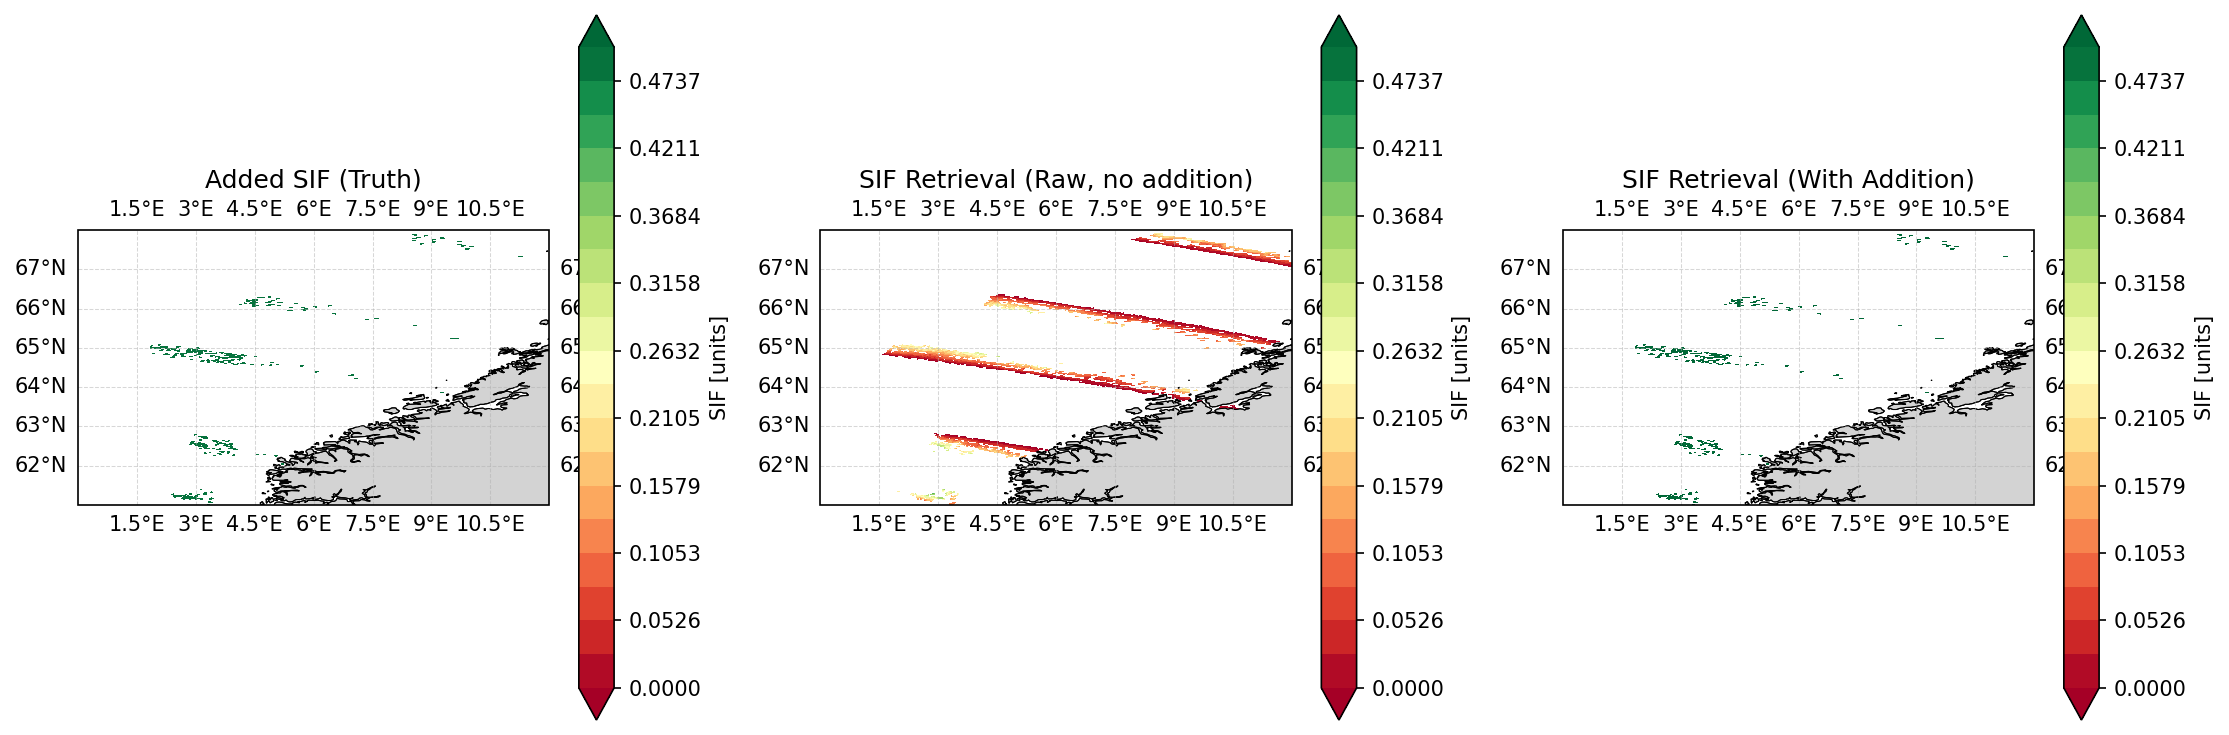

In [91]:
fig = plt.figure(figsize=(15, 5), dpi=150)

# Set extent (same as example)
buffer_bnd = 0.25
lon_min = float(lon.min()) - buffer_bnd
lon_max = float(lon.max()) + buffer_bnd
lat_min = float(lat.min()) - buffer_bnd
lat_max = float(lat.max()) + buffer_bnd
extent = [lon_min, lon_max, lat_min, lat_max]
# extent
lon_min, lon_max = 0, 12
lat_min, lat_max = 61, 68
extent = [lon_min, lon_max, lat_min, lat_max]

# Prepare levels for each plot
levels1 = np.linspace(0, .5, 20)
levels2 = np.linspace(0, .5, 20)
levels3 = np.linspace(0, .5, 20)

proj = ccrs.PlateCarree()
cmap = 'RdYlGn'

# mask the pixels that did not converge
sif_added_truth = np.where(converged_with_sif, sif_added_truth, np.nan)
sif_retrieval = np.where(converged_without_sif, sif_retrieval, np.nan)
sif_retrieval_added = np.where(converged_with_sif, sif_retrieval_added, np.nan)

# Plot 1: Added SIF (Truth)
ax1 = plt.subplot(1, 3, 1, projection=proj)
ax1.set_title("Added SIF (Truth)")
ax1.set_extent(extent, crs=proj)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im1 = ax1.contourf(lon, lat, sif_added_truth, levels=levels1, transform=proj, cmap=cmap, extend='both')
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', label="SIF [units]")

# Plot 2: Raw SIF (Retrieval without addition)
ax2 = plt.subplot(1, 3, 2, projection=proj)
ax2.set_title("SIF Retrieval (Raw, no addition)")
ax2.set_extent(extent, crs=proj)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im2 = ax2.contourf(lon, lat, sif_retrieval, levels=levels2, transform=proj, cmap=cmap, extend='both')
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', label="SIF [units]")

# Plot 3: SIF w/ addition (Retrieved + Added SIF)
ax3 = plt.subplot(1, 3, 3, projection=proj)
ax3.set_title("SIF Retrieval (With Addition)")
ax3.set_extent(extent, crs=proj)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
im3 = ax3.contourf(lon, lat, sif_retrieval_added, levels=levels3, transform=proj, cmap=cmap, extend='both')
cbar3 = plt.colorbar(im3, ax=ax3, orientation='vertical', label="SIF [units]")

plt.tight_layout()
plt.show()

(array([  1.,   0.,   0.,   0.,   0.,   1.,   0.,   4.,   0.,   2.,   0.,
          0.,   3.,   5.,   5.,   6.,  13.,  16.,  22.,  27.,  28.,  29.,
         39.,  53.,  64.,  72.,  85., 109., 130., 127., 166., 169., 203.,
        221., 232., 252., 266., 291., 296., 378., 328., 364., 379., 339.,
        388., 387., 319., 315., 330., 267., 268., 280., 247., 217., 197.,
        167., 138., 130., 101.,  86.,  96.,  77.,  64.,  55.,  31.,  42.,
         24.,  26.,  14.,  17.,  11.,   4.,   6.,   7.,   4.,   0.,   4.,
          1.,   2.,   3.,   1.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.50187838, 0.50234157, 0.50280482, 0.503268  , 0.50373119,
        0.50419438, 0.50465763, 0.50512081, 0.505584  , 0.50604725,
        0.50651044, 0.50697362, 0.50743687, 0.50790006, 0.50836325,
        0.50882649, 0.50928968, 0.50975287, 0.51021606, 0.5106793 ,
        0.51114249, 0.51160568, 0.51206893, 0.

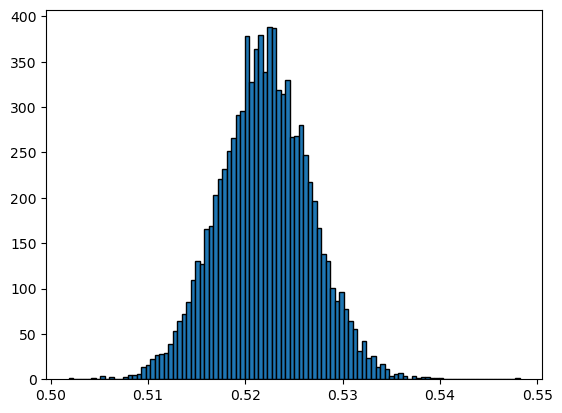

In [86]:
# plot a histogram of sif_diff
# difference
sif_diff = sif_retrieval_added - sif_retrieval
plt.hist(sif_diff.flatten(), bins=100, edgecolor='black')
# plt.xlim(-0.5, 1.5)

(-1.5, 1.5)

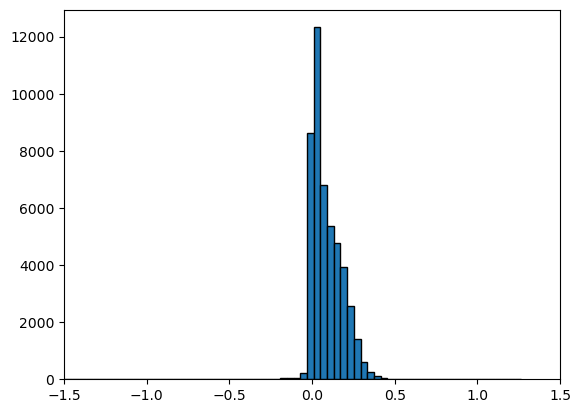

In [88]:
plt.hist(sif_retrieval.flatten(), bins=100, edgecolor='black')
plt.xlim(-1.5, 1.5)

(-1.5, 1.5)

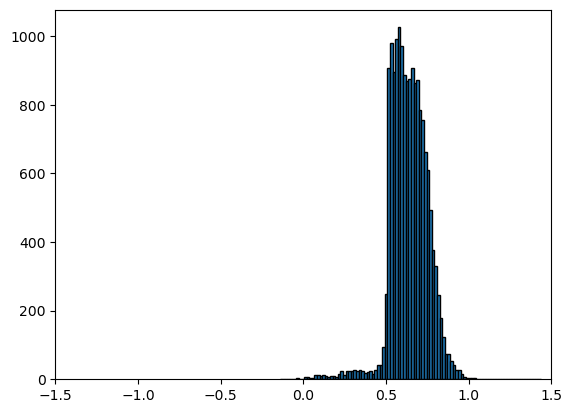

In [90]:
plt.hist(sif_retrieval_added.flatten(), bins=100, edgecolor='black')
plt.xlim(-1.5, 1.5)